In [1]:
import polars as pl
import pandas as pd
import numpy as np
import catboost
import os
from datetime import date, timedelta
import re
from sklearn.decomposition import TruncatedSVD
from sklearn.feature_extraction.text import TfidfVectorizer
import polars.selectors as cs

In [2]:
test_start_date = date(2024, 8, 1)
val_start_date = date(2024, 7, 1)
val_end_date = date(2024, 7, 31)
train_end_date = date(2024, 6, 30)
data_path = './predict-user-fresh-order/'

# Read data

In [3]:
actions_history = pl.scan_parquet(os.path.join(data_path, 'actions_history')).join(pl.scan_csv(os.path.join(data_path, 'action_type_info.csv')), on='action_type_id').drop('action_type_id').with_columns(
    pl.col('action_type').cast(pl.Categorical).alias('action_type')
)
search_history = pl.scan_parquet(os.path.join(data_path, 'search_history')).join(pl.scan_csv(os.path.join(data_path, 'action_type_info.csv')), on='action_type_id').drop('action_type_id').with_columns(
    pl.col('action_type').cast(pl.Categorical).alias('action_type')
)
product_information = pl.scan_csv(
    os.path.join(data_path, 'product_information.csv'))

In [4]:
val_start_date, val_end_date

(datetime.date(2024, 7, 1), datetime.date(2024, 7, 31))

In [5]:
val_target = (
    actions_history
    .filter(pl.col('timestamp').dt.date() >= val_start_date)
    .filter(pl.col('timestamp').dt.date() <= val_end_date)
    .select('user_id', (pl.col('action_type') == 'order').alias('has_order'))
    .group_by('user_id')
    .agg(pl.max('has_order').cast(pl.Int32).alias('target'))
)

In [6]:
val_target.group_by('target').agg(pl.count('user_id')).collect()

target,user_id
i32,u32
0,1227381
1,647575


In [7]:
val_target.group_by('target').agg(pl.count('user_id')).collect_schema()

Schema([('target', Int32), ('user_id', UInt32)])

# Simple pipeline

## Intent features

In [8]:
intent_df = actions_history.with_columns([
    pl.col("timestamp").cast(pl.Datetime),
    ]).sort(["user_id", "timestamp"])

intent_df_7d = intent_df.filter(pl.col("timestamp") >= train_end_date - timedelta(days=7))
intent_df_30d = intent_df.filter(pl.col("timestamp") >= train_end_date - timedelta(days=30))

In [9]:
agg_7d = intent_df_7d.group_by("user_id").agg([
    (pl.col("action_type") == "to_cart").sum().alias("add_to_cart_count_7d"),
    (pl.col("action_type") == "click").sum().alias("product_clicks_7d"),
])

agg_30d = intent_df_30d.group_by("user_id").agg([
    (pl.col("action_type") == "to_cart").sum().alias("add_to_cart_count_30d"),
    (pl.col("action_type") == "view").sum().alias("view_count_30d"),
    (pl.col("action_type") == "search").sum().alias("search_count_30d"),
    (pl.col("action_type") == "click").sum().alias("click_count_30d"),
])

In [10]:
ratios = agg_30d.with_columns([
    ((pl.col("add_to_cart_count_30d") + 1) / (pl.col("click_count_30d") + 1))
    .fill_nan(0)
    .fill_null(0)
    .alias("cart_to_click_ratio"),
]).select(('user_id', 'cart_to_click_ratio'))

## Session features

In [11]:
df_sessions = (
    intent_df
    .with_columns([
        pl.col("timestamp").diff().over("user_id").dt.total_seconds().alias("time_diff_sec"),
    ])
    .with_columns([
        (
            (pl.col("time_diff_sec") > timedelta(minutes=40))
            .fill_null(True)
            .cast(pl.Int8)
        ).alias("new_session_flag")
    ])
    .with_columns([
        pl.col("new_session_flag").cum_sum().over("user_id").alias("session_id")
    ])
)

session_stats = df_sessions.group_by(["user_id", "session_id"]).agg([
    pl.len().alias("session_len")
])

session_agg = session_stats.group_by("user_id").agg([
    pl.col("session_len").mean().alias("avg_actions_per_session"),
    pl.col("session_len").max().alias("max_actions_per_session"),
])

In [12]:
last_actions = (
    intent_df
    .group_by("user_id")
    .agg([
        pl.col("action_type").tail(3).alias("last_3_actions")
    ])
    .with_columns([
        pl.col("last_3_actions").list.len().alias("last_actions_count"),

        pl.col("last_3_actions").list.get(-1, null_on_oob=True).fill_null("NONE").alias("last_action"),
        pl.col("last_3_actions").list.get(-2, null_on_oob=True).fill_null("NONE").alias("last_2_action"),
        pl.col("last_3_actions").list.get(-3, null_on_oob=True).fill_null("NONE").alias("last_3_action"),
    ])
    .with_columns([
        pl.concat_str(
            [
                pl.col("last_3_action"),
                pl.col("last_2_action"),
                pl.col("last_action"),
            ],
            separator="__"
        ).alias("last_3_actions_str")
    ])
).drop('last_3_actions')

In [13]:
actions_feats = (
    agg_7d
    .join(agg_30d, on="user_id", how="full", coalesce=True)
    .join(ratios, on="user_id", how="full", coalesce=True)
    .join(session_stats, on="user_id", how="full", coalesce=True)
    .join(session_agg, on="user_id", how="full", coalesce=True)
    .join(last_actions, on="user_id", how="full", coalesce=True)
)

In [14]:
actions_feats.collect(engine="streaming")

user_id,add_to_cart_count_7d,product_clicks_7d,add_to_cart_count_30d,view_count_30d,search_count_30d,click_count_30d,cart_to_click_ratio,session_id,session_len,avg_actions_per_session,max_actions_per_session,last_actions_count,last_action,last_2_action,last_3_action,last_3_actions_str
i32,u32,u32,u32,u32,u32,u32,f64,i64,u32,f64,u32,u32,cat,cat,cat,str
10459349,null,null,null,null,null,null,null,1,5,5.0,5,3,"""to_cart""","""click""","""to_cart""","""to_cart__click__to_cart"""
6437831,null,null,null,null,null,null,null,1,46,46.0,46,3,"""click""","""click""","""click""","""click__click__click"""
2280725,null,null,null,null,null,null,null,1,2,2.0,2,2,"""to_cart""","""click""","""NONE""","""NONE__click__to_cart"""
1063425,0,0,0,0,0,0,1.0,1,1,1.0,1,1,"""order""","""NONE""","""NONE""","""NONE__NONE__order"""
212729,1,1,1,0,0,1,1.0,1,2,2.0,2,2,"""to_cart""","""click""","""NONE""","""NONE__click__to_cart"""
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
7000447,null,null,2,0,0,0,3.0,1,12,12.0,12,3,"""to_cart""","""to_cart""","""to_cart""","""to_cart__to_cart__to_cart"""
9976820,0,1,0,0,0,1,0.5,1,1,1.0,1,1,"""click""","""NONE""","""NONE""","""NONE__NONE__click"""
10414544,null,null,null,null,null,null,null,1,38,38.0,38,3,"""to_cart""","""to_cart""","""to_cart""","""to_cart__to_cart__to_cart"""


## Search

In [15]:
N_SVD_COMPONENTS = 16
MIN_DF = 5
MAX_DF = 0.8
MAX_FEATURES = 5000

In [16]:
PRODUCT_KEYWORDS = [
    "молоко",
    "сыр",
    "творог",
    "йогурт",
    "кефир",
    "батон",
    "хлеб",
    "яйца",
    "курица",
    "банан",
    "яблок",
    "кофе",
    "чай",
    "шоколад",
    "вода",
    "колбас",
]


In [17]:
def normalize_query_expr(col_name: str = "search_query") -> pl.Expr:
    """
    Нормализация текста запроса средствами Polars.
    """
    return (
        pl.col(col_name)
        .cast(pl.String)
        .str.to_lowercase()
        .str.replace_all(r"ё", "е")
        .str.replace_all(r"[^a-zа-я0-9\s]+", " ")
        .str.replace_all(r"\s+", " ")
        .str.strip_chars()
    )

In [18]:
def build_keyword_flag_exprs(
    query_col: str,
    prefixes: list[str],
    prefix_name: str,
) -> list[pl.Expr]:
    """
    Строит булевы признаки по наличию подстрок/префиксов в запросе.
    """
    exprs = []
    for kw in prefixes:
        safe = re.sub(r"[^a-zA-Zа-яА-Я0-9]+", "_", kw.lower()).strip("_")
        exprs.append(
            pl.col(query_col)
            .str.contains(re.escape(kw), literal=False)
            .fill_null(False)
            .cast(pl.Int8)
            .alias(f"{prefix_name}_{safe}_flag")
        )
    return exprs


In [19]:
search_df = (
    search_history
    .with_columns([
        pl.col("timestamp").cast(pl.Datetime),
        normalize_query_expr("search_query").alias("search_query_norm"),
    ])
    .filter(pl.col("timestamp").dt.date() <= train_end_date)
    .sort(["user_id", "timestamp"])
)

In [20]:
search_7d = search_df.filter(pl.col('timestamp').dt.date() >= train_end_date - timedelta(days=7))
search_30d = search_df.filter(pl.col('timestamp').dt.date() >= train_end_date - timedelta(days=30))

In [21]:
query_level = (
    search_df
    .with_columns([
        pl.col("search_query_norm").str.len_chars().alias("query_len_chars"),
        pl.col("search_query_norm").str.split(" ").list.len().alias("query_len_words"),
    ] + build_keyword_flag_exprs("search_query_norm", PRODUCT_KEYWORDS, "product"))
)

In [22]:
query_level_30d = query_level.filter(pl.col("timestamp").dt.date() >= train_end_date - timedelta(days=30) )
query_level_7d = query_level.filter(pl.col("timestamp").dt.date() >= train_end_date - timedelta(days=7))

In [23]:
basic_30d = query_level_30d.group_by("user_id").agg([
    pl.len().alias("search_count_30d"),
    pl.col("search_query_norm").n_unique().alias("unique_queries_30d"),
    pl.col("query_len_chars").mean().alias("avg_query_len_chars_30d"),
    pl.col("query_len_chars").median().alias("median_query_len_chars_30d"),
    pl.col("query_len_words").mean().alias("avg_query_len_words_30d"),
    pl.col("query_len_words").max().alias("max_query_len_words_30d"),
])

basic_7d = query_level_7d.group_by("user_id").agg([
    pl.len().alias("search_count_7d"),
    pl.col("search_query_norm").n_unique().alias("unique_queries_7d"),
])

In [24]:
recency = search_df.group_by("user_id").agg([
    (train_end_date - pl.col("timestamp").max().dt.date()).dt.total_days()
    .alias("days_since_last_search")
])

### Text features

In [25]:
product_flag_cols = [f"product_{re.sub(r'[^a-zA-Zа-яА-Я0-9]+', '_', kw.lower()).strip('_')}_flag"
                     for kw in PRODUCT_KEYWORDS]

keyword_aggs = []

In [26]:
for col in product_flag_cols:
    keyword_aggs.extend([
        pl.col(col).sum().alias(f"{col}_count_30d"),
        pl.col(col).mean().alias(f"{col}_rate_30d"),
    ])

In [27]:
keyword_features = query_level_30d.group_by("user_id").agg(keyword_aggs)

keyword_summary = query_level_30d.group_by("user_id").agg([
    pl.sum_horizontal(product_flag_cols).sum().alias("product_keyword_hits_30d"),
    (pl.sum_horizontal(product_flag_cols) > 0).sum().alias("queries_with_product_keywords_30d"),
])

In [28]:
user_docs = (
    search_30d
    .group_by("user_id")
    .agg([
        pl.col("search_query_norm").str.concat(" ").alias("all_queries_text_30d"),
        pl.len().alias("search_count_for_text"),
    ])
).collect(engine="streaming")

/tmp/ipykernel_126993/1132034654.py:5: DeprecationWarning: `str.concat` is deprecated; use `str.join` instead. Note also that the default `delimiter` for `str.join` is an empty string, not a hyphen.
  pl.col("search_query_norm").str.concat(" ").alias("all_queries_text_30d"),


In [29]:
user_docs_pd = user_docs.to_pandas()

In [30]:
vectorizer = TfidfVectorizer(
        analyzer="word",
        ngram_range=(1, 2),
        min_df=MIN_DF,
        max_df=MAX_DF,
        max_features=MAX_FEATURES,
        sublinear_tf=True,
    )

X_tfidf = vectorizer.fit_transform(user_docs_pd["all_queries_text_30d"].fillna(""))

In [31]:
svd = TruncatedSVD(n_components=N_SVD_COMPONENTS)
X_svd = svd.fit_transform(X_tfidf)

In [32]:
svd_cols = [f"search_tfidf_svd_{i:02d}" for i in range(X_svd.shape[1])]

tfidf_svd_features = pl.DataFrame({
    "user_id": user_docs_pd["user_id"].tolist(),
    **{col: X_svd[:, i].tolist() for i, col in enumerate(svd_cols)}
}).with_columns(
    pl.col('user_id').cast(pl.Int32)
)

### Last search actions

In [33]:
last_query_features = (
    query_level
    .group_by("user_id")
    .agg([
        pl.col("search_query_norm").last().alias("last_search_query"),
        pl.col("query_len_chars").last().alias("last_search_len_chars"),
        pl.col("query_len_words").last().alias("last_search_len_words"),
    ])
)

In [34]:
last_query_features = last_query_features.with_columns([
    *[
        pl.col("last_search_query")
        .str.contains(re.escape(kw), literal=False)
        .fill_null(False)
        .cast(pl.Int8)
        .alias(f"last_query_product_{re.sub(r'[^a-zA-Zа-яА-Я0-9]+', '_', kw.lower()).strip('_')}")
        for kw in PRODUCT_KEYWORDS
    ],
])

In [35]:
search_features = (
    basic_30d.lazy()
    .join(recency.lazy(), on="user_id", how="full", coalesce=True)
    .join(keyword_features.lazy(), on="user_id", how="full", coalesce=True)
    .join(keyword_summary.lazy(), on="user_id", how="full", coalesce=True)
    .join(tfidf_svd_features.lazy(), on="user_id", how="full", coalesce=True)
    .join(last_query_features.lazy(), on="user_id", how="full", coalesce=True)
    .join(basic_7d.lazy(), on="user_id", how="full", coalesce=True)
)

In [36]:
search_features.collect(engine="streaming")

user_id,search_count_30d,unique_queries_30d,avg_query_len_chars_30d,median_query_len_chars_30d,avg_query_len_words_30d,max_query_len_words_30d,days_since_last_search,product_молоко_flag_count_30d,product_молоко_flag_rate_30d,product_сыр_flag_count_30d,product_сыр_flag_rate_30d,product_творог_flag_count_30d,product_творог_flag_rate_30d,product_йогурт_flag_count_30d,product_йогурт_flag_rate_30d,product_кефир_flag_count_30d,product_кефир_flag_rate_30d,product_батон_flag_count_30d,product_батон_flag_rate_30d,product_хлеб_flag_count_30d,product_хлеб_flag_rate_30d,product_яйца_flag_count_30d,product_яйца_flag_rate_30d,product_курица_flag_count_30d,product_курица_flag_rate_30d,product_банан_flag_count_30d,product_банан_flag_rate_30d,product_яблок_flag_count_30d,product_яблок_flag_rate_30d,product_кофе_flag_count_30d,product_кофе_flag_rate_30d,product_чай_flag_count_30d,product_чай_flag_rate_30d,product_шоколад_flag_count_30d,product_шоколад_flag_rate_30d,product_вода_flag_count_30d,…,search_tfidf_svd_00,search_tfidf_svd_01,search_tfidf_svd_02,search_tfidf_svd_03,search_tfidf_svd_04,search_tfidf_svd_05,search_tfidf_svd_06,search_tfidf_svd_07,search_tfidf_svd_08,search_tfidf_svd_09,search_tfidf_svd_10,search_tfidf_svd_11,search_tfidf_svd_12,search_tfidf_svd_13,search_tfidf_svd_14,search_tfidf_svd_15,last_search_query,last_search_len_chars,last_search_len_words,last_query_product_молоко,last_query_product_сыр,last_query_product_творог,last_query_product_йогурт,last_query_product_кефир,last_query_product_батон,last_query_product_хлеб,last_query_product_яйца,last_query_product_курица,last_query_product_банан,last_query_product_яблок,last_query_product_кофе,last_query_product_чай,last_query_product_шоколад,last_query_product_вода,last_query_product_колбас,search_count_7d,unique_queries_7d
i32,u32,u32,f64,f64,f64,u32,i64,i64,f64,i64,f64,i64,f64,i64,f64,i64,f64,i64,f64,i64,f64,i64,f64,i64,f64,i64,f64,i64,f64,i64,f64,i64,f64,i64,f64,i64,…,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,str,u32,u32,i8,i8,i8,i8,i8,i8,i8,i8,i8,i8,i8,i8,i8,i8,i8,i8,u32,u32
5062251,null,null,null,null,null,null,75,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,…,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,"""чипсы чушпан""",12,2,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,null,null
4904311,null,null,null,null,null,null,105,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,…,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,"""крылья куриные""",14,2,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,null,null
3439251,40,37,8.4,7.0,1.3,3,1,0,0.0,0,0.0,1,0.025,0,0.0,0,0.0,1,0.025,0,0.0,1,0.025,0,0.0,1,0.025,0,0.0,0,0.0,0,0.0,0,0.0,0,…,0.100489,-0.121642,-0.041802,-0.004509,-0.067762,-0.029463,-0.040157,-0.010891,0.097923,0.074397,-0.092799,-0.052387,0.039499,-0.010892,-0.040715,-0.057969,"""корзинка с ягодами""",18,3,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,33,32
2863917,4,4,15.25,16.5,2.25,3,18,0,0.0,0,0.0,0,0.0,0,0.0,0,0.0,0,0.0,0,0.0,0,0.0,0,0.0,0,0.0,0,0.0,0,0.0,0,0.0,0,0.0,0,…,0.16632,0.096546,0.005191,-0.072211,0.008451,-0.000598,-0.000419,-0.01271,-0.018096,-0.003293,-0.013202,-0.003935,-0.04208,-0.010159,-0.013713,-0.014274,"""для мытья окон""",14,3,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,null,null
8954774,8,6,10.25,8.0,1.625,3,5,0,0.0,0,0.0,0,0.0,0,0.0,0,0.0,0,0.0,0,0.0,0,0.0,0,0.0,0,0.0,0,0.0,0,0.0,0,0.0,0,0.0,0,…,0.14118,0.062263,0.001497,-0.072075,0.002277,0.004905,-0.002506,-0.010108,0.002717,0.00279,0.026552,0.007248,0.038476,0.003875,0.004234,0.012276,"""сигареты""",8,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,3,2
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
3623957,1,1,10.0,10.0,2.0,2,30,0,0.0,0,0.0,0,0.0,0,0.0,0,0.0,0,0.0,0,0.0,0,0.0

## Price features

In [37]:
TOP_K_CATEGORIES = 10

PRODUCT_ACTIONS = ["view", "click", "to_cart", "favorite", "order"]

PRICE_ACTIONS = ["view", "click", "to_cart", "order"]

In [38]:
actions_df = (    
    actions_history
    .filter(pl.col("timestamp").dt.date() <= train_end_date)
    .filter(pl.col("timestamp").dt.date() >= train_end_date - timedelta(days = 30 * 4))
    .filter(pl.col("product_id").is_not_null())
)

products_df = (
    product_information
    .with_columns([
        pl.col("price").cast(pl.Float64),
        pl.col("discount_price").cast(pl.Float64),
        pl.col("category_id").cast(pl.Int64),
        pl.col("category_name").cast(pl.String),
        pl.col("brand").cast(pl.String),
        pl.col("type").cast(pl.String),
    ])
    .select([
        "product_id",
        "brand",
        "type",
        "category_id",
        "category_name",
        "price",
        "discount_price",
    ])
)

In [39]:
events = (
    actions_df
    .join(products_df, on="product_id", how="left")
    .with_columns([
        pl.when(
            pl.col("discount_price").is_not_null() &
            (pl.col("discount_price") > 0)
        )
        .then(pl.col("discount_price"))
        .otherwise(pl.col("price"))
        .alias("effective_price"),

        pl.when(
            pl.col("price").is_not_null() &
            (pl.col("price") > 0) &
            pl.col("discount_price").is_not_null() &
            (pl.col("discount_price") >= 0) &
            (pl.col("discount_price") <= pl.col("price"))
        )
        .then((pl.col("price") - pl.col("discount_price")) / pl.col("price"))
        .otherwise(0.0)
        .alias("discount_ratio"),

        pl.when(
            pl.col("price").is_not_null() &
            pl.col("discount_price").is_not_null() &
            (pl.col("price") > pl.col("discount_price"))
        )
        .then(1)
        .otherwise(0)
        .cast(pl.Int8)
        .alias("is_discounted")
    ])
)

In [40]:
product_events = events.filter(pl.col("action_type").is_in(PRODUCT_ACTIONS))
price_events = events.filter(pl.col("action_type").is_in(PRICE_ACTIONS))

In [41]:
price_features = (
    price_events
    .group_by("user_id")
    .agg([
        pl.col("effective_price").mean().alias("avg_viewed_price"),
        pl.col("effective_price").median().alias("median_viewed_price"),
        pl.col("effective_price").max().alias("max_viewed_price"),
        pl.col("discount_ratio").mean().alias("discount_ratio_mean"),
        pl.col("is_discounted").mean().alias("fraction_discounted_products"),
    ])
)

In [42]:
price_features.collect(engine="streaming")

user_id,avg_viewed_price,median_viewed_price,max_viewed_price,discount_ratio_mean,fraction_discounted_products
i32,f64,f64,f64,f64,f64
8015022,209.0,209.0,209.0,0.0,0.0
2709298,748.0,742.5,1368.0,0.213194,1.0
4308467,139.363636,112.0,359.0,0.162338,0.454545
5443096,390.0,390.0,390.0,0.25,1.0
1421693,441.0,319.0,1009.0,0.0,0.0
…,…,…,…,…,…
82048,2995.5,2995.5,4787.0,0.013443,1.0
10869793,220.064189,119.0,8500.0,0.100307,0.52027
6916823,214.040816,174.0,785.0,0.04338,0.265306


## Category features

In [43]:
user_category_counts = (
    product_events
    .filter(pl.col("category_id").is_not_null())
    .group_by(["user_id", "category_id", "category_name"])
    .agg([
        pl.len().alias("category_event_count")
    ])
)

user_category_totals = (
    user_category_counts
    .group_by("user_id")
    .agg([
        pl.col("category_event_count").sum().alias("total_category_events"),
        pl.col("category_event_count").max().alias("favorite_category_count"),
        pl.len().alias("unique_categories"),
    ])
    .with_columns([
        (
            pl.col("favorite_category_count") /
            pl.col("total_category_events")
        ).alias("favorite_category_share")
    ])
)

In [44]:
category_entropy = (
    user_category_counts
    .join(
        user_category_totals.select(["user_id", "total_category_events"]),
        on="user_id",
        how="left"
    )
    .with_columns([
        (pl.col("category_event_count") / pl.col("total_category_events")).alias("p_cat")
    ])
    .with_columns([
        pl.when(pl.col("p_cat") > 0)
        .then(-pl.col("p_cat") * pl.col("p_cat").log())
        .otherwise(0.0)
        .alias("entropy_term")
    ])
    .group_by("user_id")
    .agg([
        pl.col("entropy_term").sum().alias("category_entropy")
    ])
)

In [45]:
top_categories = (
    product_events
    .filter(pl.col("category_id").is_not_null())
    .group_by(["category_id", "category_name"])
    .agg(pl.len().alias("global_category_count"))
    .sort("global_category_count", descending=True)
    .head(TOP_K_CATEGORIES)
).collect(engine="streaming")

top_category_ids = top_categories["category_id"].to_list()

In [46]:
user_top_category_features = (
    product_events
    .filter(pl.col("category_id").is_in(top_category_ids))
    .group_by(["user_id", "category_id"])
    .agg(pl.len().alias("cnt"))
    .join(
        user_category_totals.select(["user_id", "total_category_events"]),
        on="user_id",
        how="left"
    )
    .with_columns([
        (pl.col("cnt") / pl.col("total_category_events")).alias("share")
    ])
    .collect(engine="streaming")
    .pivot(
        values="share",
        index="user_id",
        on="category_id",
        aggregate_function="first"
    )
    .fill_null(0)
)

In [47]:
rename_map = {
    col: f"top_category_share_{col}"
    for col in user_top_category_features.columns
    if col != "user_id"
}
user_top_category_features = user_top_category_features.rename(rename_map).fill_null(0)

In [48]:
category_features = (
    user_category_totals
    .join(category_entropy, on="user_id", how="full", coalesce=True)
    .join(user_top_category_features.lazy(), on="user_id", how="full", coalesce=True)
)

In [49]:
category_features.collect(engine="streaming")

user_id,total_category_events,favorite_category_count,unique_categories,favorite_category_share,category_entropy,top_category_share_512,top_category_share_553,top_category_share_413,top_category_share_224,top_category_share_404,top_category_share_829,top_category_share_236,top_category_share_601,top_category_share_623,top_category_share_483
i32,u32,u32,u32,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
3183082,5,3,3,0.6,0.950271,null,null,null,null,null,null,null,null,null,null
2685320,1,1,1,1.0,0.0,null,null,null,null,null,null,null,null,null,null
8198300,3,3,1,1.0,0.0,null,null,null,null,null,null,null,null,null,null
6761052,31,8,10,0.258065,2.084261,null,null,null,null,null,null,null,null,null,null
4350120,1,1,1,1.0,0.0,null,null,null,null,null,null,null,null,null,null
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
1622936,3,2,2,0.666667,0.636514,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.666667,0.0
1579050,3,1,3,0.333333,1.098612,null,null,null,null,null,null,null,null,null,null
7976271,1,1,1,1.0,0.0,null,null,null,null,null,null,null,null,null,null


## Feats

In [50]:
actions_aggs = {}
actions_id_to_suf = {
    1: "click",
    2: "favorite",
    3: "order",
    5: "to_cart",
}
for id_, suf in actions_id_to_suf.items():
    aggs = (
        actions_history
        .filter(pl.col('timestamp').dt.date() <= train_end_date)
        .filter(pl.col('timestamp').dt.date() >= train_end_date - timedelta(days=30 * 4))
        .filter(pl.col('action_type') == actions_id_to_suf[id_])
        .join(
            product_information
            .select('product_id', 'discount_price'),
            on='product_id',
        )
        .group_by('user_id')
        .agg(
            pl.count('product_id').cast(pl.Int32).alias(f'num_products_{suf}'),
            pl.sum('discount_price').cast(pl.Float32).alias(f'sum_discount_price_{suf}'),
            pl.max('discount_price').cast(pl.Float32).alias(f'max_discount_price_{suf}'),
            pl.max('timestamp').alias(f'last_{suf}_time'),
            pl.min('timestamp').alias(f'first_{suf}_time'),
        )
        .with_columns([
            (pl.lit(val_start_date) - pl.col(f'last_{suf}_time'))
            .dt.total_days()
            .cast(pl.Int32)
            .alias(f'days_since_last_{suf}'),
            
            (pl.lit(val_start_date) - pl.col(f'first_{suf}_time'))
            .dt.total_days()
            .cast(pl.Int32)
            .alias(f'days_since_first_{suf}'),
        ])
        .select(
            'user_id',
            f'num_products_{suf}',
            f'sum_discount_price_{suf}',
            f'max_discount_price_{suf}',
            f'days_since_last_{suf}',
            f'days_since_first_{suf}',
        )
    )
    actions_aggs[id_] = aggs

In [51]:
# search_aggs
suf = 'search'
actions_aggs[suf] = (
    search_history
    .filter(pl.col('action_type') == "search")
    .filter(pl.col('timestamp').dt.date() <= train_end_date)
    .filter(pl.col('timestamp').dt.date() >= train_end_date - timedelta(days=30 * 4))
    .group_by('user_id')
    .agg(
        pl.count('search_query').cast(pl.Int32).alias(f'num_{suf}'),
        pl.max('timestamp').alias(f'last_{suf}_time'),
        pl.min('timestamp').alias(f'first_{suf}_time'),
    )
    .with_columns([
        (pl.lit(val_start_date) - pl.col(f'last_{suf}_time'))
        .dt.total_days()
        .cast(pl.Int32)
        .alias(f'days_since_last_{suf}'),

        (pl.lit(val_start_date) - pl.col(f'first_{suf}_time'))
        .dt.total_days()
        .cast(pl.Int32)
        .alias(f'days_since_first_{suf}'),
    ])
    .select(
        'user_id',
        f'num_{suf}',
        f'days_since_last_{suf}',
        f'days_since_first_{suf}',
    )
)

In [52]:
actions_aggs.keys()

dict_keys([1, 2, 3, 5, 'search'])

In [71]:
df = val_target
for _, actions_aggs_df in actions_aggs.items():
    df = (
        df
        .join(actions_aggs_df, on='user_id', how='left')
    )

df = (
    df
    .join(actions_feats, how="left", on='user_id')
    .join(search_features, how="left", on='user_id')
    .join(price_features, how="left", on='user_id')
    .join(category_features, how="left", on='user_id')
    .with_columns(
        cs.numeric().fill_null(strategy="zero"),
        cs.string().fill_null("")
    )
).collect(engine="streaming")

In [72]:
df

user_id,target,num_products_click,sum_discount_price_click,max_discount_price_click,days_since_last_click,days_since_first_click,num_products_favorite,sum_discount_price_favorite,max_discount_price_favorite,days_since_last_favorite,days_since_first_favorite,num_products_order,sum_discount_price_order,max_discount_price_order,days_since_last_order,days_since_first_order,num_products_to_cart,sum_discount_price_to_cart,max_discount_price_to_cart,days_since_last_to_cart,days_since_first_to_cart,num_search,days_since_last_search,days_since_first_search,add_to_cart_count_7d,product_clicks_7d,add_to_cart_count_30d,view_count_30d,search_count_30d,click_count_30d,cart_to_click_ratio,session_id,session_len,avg_actions_per_session,max_actions_per_session,last_actions_count,…,last_query_product_сыр,last_query_product_творог,last_query_product_йогурт,last_query_product_кефир,last_query_product_батон,last_query_product_хлеб,last_query_product_яйца,last_query_product_курица,last_query_product_банан,last_query_product_яблок,last_query_product_кофе,last_query_product_чай,last_query_product_шоколад,last_query_product_вода,last_query_product_колбас,search_count_7d,unique_queries_7d,avg_viewed_price,median_viewed_price,max_viewed_price,discount_ratio_mean,fraction_discounted_products,total_category_events,favorite_category_count,unique_categories,favorite_category_share,category_entropy,top_category_share_512,top_category_share_553,top_category_share_413,top_category_share_224,top_category_share_404,top_category_share_829,top_category_share_236,top_category_share_601,top_category_share_623,top_category_share_483
i32,i32,i32,f32,f32,i32,i32,i32,f32,f32,i32,i32,i32,f32,f32,i32,i32,i32,f32,f32,i32,i32,i32,i32,i32,u32,u32,u32,u32,u32,u32,f64,i64,u32,f64,u32,u32,…,i8,i8,i8,i8,i8,i8,i8,i8,i8,i8,i8,i8,i8,i8,i8,u32,u32,f64,f64,f64,f64,f64,u32,u32,u32,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
1704776,0,4,1646.0,902.0,20,37,0,0.0,0.0,0,0,0,0.0,0.0,0,0,2,560.0,376.0,37,37,6,5,37,1,0,1,0,0,1,1.0,1,7,7.0,7,3,…,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,1,367.666667,280.0,902.0,0.52557,1.0,6,3,3,0.5,1.011404,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2103781,1,0,0.0,0.0,0,0,0,0.0,0.0,0,0,9,1055.0,210.0,31,31,8,1046.0,210.0,31,31,4,31,31,5,1,5,0,0,1,3.0,1,28,28.0,28,3,…,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,123.588235,145.0,210.0,0.090822,0.588235,17,6,4,0.352941,1.242255,0.0,0.058824,0.0,0.0,0.0,0.0,0.352941,0.0,0.0,0.0
5867686,0,4,17898.0,7559.0,101,101,1,7559.0,7559.0,101,101,0,0.0,0.0,0,0,0,0.0,0.0,0,0,3,101,101,1,0,1,0,0,0,2.0,1,6,6.0,6,3,…,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,4474.5,4718.5,7559.0,0.141095,1.0,5,5,1,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
7403006,0,2,2263.0,1192.0,83,83,0,0.0,0.0,0,0,0,0.0,0.0,0,0,5,1421.0,1192.0,81,83,0,0,0,2,1,2,0,0,1,1.5,1,10,10.0,10,3,…,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,526.285714,60.0,1192.0,0.085715,0.571429,7,3,3,0.428571,1.004242,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3530188,0,0,0.0,0.0,0,0,0,0.0,0.0,0,0,0,0.0,0.0,0,0,2,178.0,89.0,102,102,0,0,0,2,0,2,0,0,0,3.0,1,4,4.0,4,3,…,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,89.0,89.0,89.0,0.183486,1.0,2,2,1,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
7503430,0,0,0.0,0.0,0,0,0,0.0,0.0,0,0,0,0.0,0.0,0,0,0,0.0,0.0,0,0,0,0,0,1,1,1,0,0,1,1.0,1,3,3.0,3,3,…,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
9184263,0,0,0.0,0.0,0,0,0,0.0,0.0,0,0,0,0.0,0.0,0,0,0,0.0,0.0,0,0,1,38,38,0,1,0,0,0,1,0.5,1,2,2.0,2,2,…,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
10394057,0,0,0.0,0.0,0,0,0,0.0,0.0,0,0,0,0.0,0.0,0,0,0,0.0,0.0,0,0,3,60,116,0,1,0,0,0,1,0.5,1,2,2.0,2,2,…,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [73]:
df_pd = df.to_pandas()

In [74]:
mask = df_pd.user_id % 10 <= 6

## Обработка данных

Сначала посмотрим на данные

In [75]:
from utils import plot_float_feature_histograms
from utils2 import AutoFeatureStandardizer

In [76]:
X = df_pd.drop(columns=['user_id', 'target'])
y = df_pd.loc[:].target

In [ ]:
# fig, axes = plot_float_feature_histograms(
#     dataset=(X, y),
#     class_0_label="False",
#     class_1_label="True",
# )

TypeError: Cannot interpret 'CategoricalDtype(categories=['order', 'to_cart', 'click', 'favorite'], ordered=False, categories_dtype=object)' as a data type

In [ ]:
# std = AutoFeatureStandardizer(add_indicators=False)

# X_transformed = std.fit_transform(X)
# fig, axes = plot_float_feature_histograms(
#     dataset=(X_transformed, y),
#     class_0_label="False",
#     class_1_label="True",
# )

# X = X_transformed

TypeError: Cannot interpret 'CategoricalDtype(categories=['order', 'to_cart', 'click', 'favorite'], ordered=False, categories_dtype=object)' as a data type

In [77]:
X_train = X.loc[mask, :]
y_train = y.loc[mask]
X_val = X.loc[~mask, :]
y_val = y.loc[~mask]

In [78]:
params = {
    'iterations': 2000,
    'depth': 7, 
    'learning_rate': 0.05, 
    'random_state': 1,
    'eval_metric': 'AUC',
    'loss_function': 'Logloss',
    'auto_class_weights': 'Balanced',
    'task_type': 'GPU',
    'cat_features': list(df_pd.select_dtypes(include='category').columns) + list(df_pd.select_dtypes(include='object').columns)
}

In [79]:
model = catboost.CatBoostClassifier(**params)
model.fit(X_train, y_train, early_stopping_rounds=50, use_best_model=True, eval_set=(X_val, y_val))

Default metric period is 5 because AUC is/are not implemented for GPU


0:	test: 0.9848594	best: 0.9848594 (0)	total: 118ms	remaining: 3m 55s
1:	total: 170ms	remaining: 2m 50s
2:	total: 232ms	remaining: 2m 34s
3:	total: 293ms	remaining: 2m 26s
4:	total: 349ms	remaining: 2m 19s
5:	test: 0.9874035	best: 0.9874035 (5)	total: 410ms	remaining: 2m 16s
6:	total: 471ms	remaining: 2m 14s
7:	total: 524ms	remaining: 2m 10s
8:	total: 574ms	remaining: 2m 6s
9:	total: 627ms	remaining: 2m 4s
10:	test: 0.9876285	best: 0.9876285 (10)	total: 681ms	remaining: 2m 3s
11:	total: 733ms	remaining: 2m 1s
12:	total: 785ms	remaining: 2m
13:	total: 838ms	remaining: 1m 58s
14:	total: 891ms	remaining: 1m 57s
15:	test: 0.9877390	best: 0.9877390 (15)	total: 937ms	remaining: 1m 56s
16:	total: 985ms	remaining: 1m 54s
17:	total: 1.03s	remaining: 1m 53s
18:	total: 1.08s	remaining: 1m 52s
19:	total: 1.13s	remaining: 1m 51s
20:	test: 0.9879982	best: 0.9879982 (20)	total: 1.17s	remaining: 1m 50s
21:	total: 1.22s	remaining: 1m 49s
22:	total: 1.26s	remaining: 1m 48s
23:	total: 1.31s	remaining: 1m

## Версия 0.1
Ну в изначальном решении на первый бейзлайн какой-то кринж получился, так что начнём издевательство над моделью тут

In [80]:
from utils2 import BinaryClassifierInterpreter
import matplotlib.pyplot as plt

In [81]:
interpreter = BinaryClassifierInterpreter(
    train=(X_train, y_train),
    val=(X_val, y_val),
    model=model,
    enable_early_stopping=True,
    use_best_model=True,
    early_stopping_rounds=100,
)

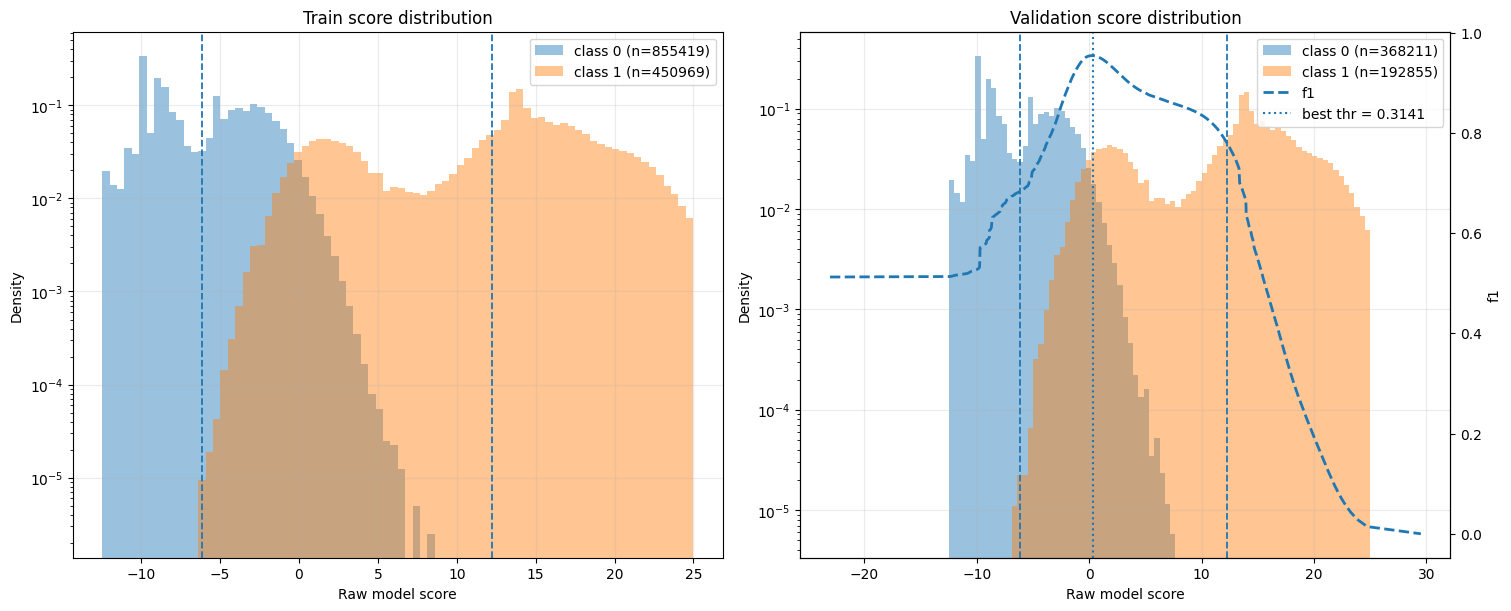

In [82]:
interpreter.plot_score_histograms_with_val_metric(val_metric_name="f1", use_log_density_y=True);

Ну уже видна лажа номер 1 - у нас есть уж очень частый скор и он точно не помогает нам различать два класса (в районе -0.7 если оценивать на глаз). Это надо будет поисследовать. Также можно увидеть, что две гистограммы в целом довольно сильно друг на друга наползают. 

ScoreFeatureContourPlotResult(fitted_model=<catboost.core.CatBoostClassifier object at 0x7fc8a4195010>, fig=<Figure size 1600x700 with 6 Axes>, train_scores=array([-0.80626771, -0.80626771, -0.80626771, ...,  0.63865388,
       -0.80626771, -0.80626771], shape=(1311636,)), val_scores=array([-0.96670193,  1.98842045, -0.80626771, ..., -0.80626771,
       -0.80626771,  0.1199301 ], shape=(563320,)), train_feature_values=array([nan, nan, nan, ..., nan, nan, nan], shape=(1311636,)), val_feature_values=array([ 6.08677473, 10.20850598,         nan, ...,         nan,
               nan,  6.29156914], shape=(563320,)))

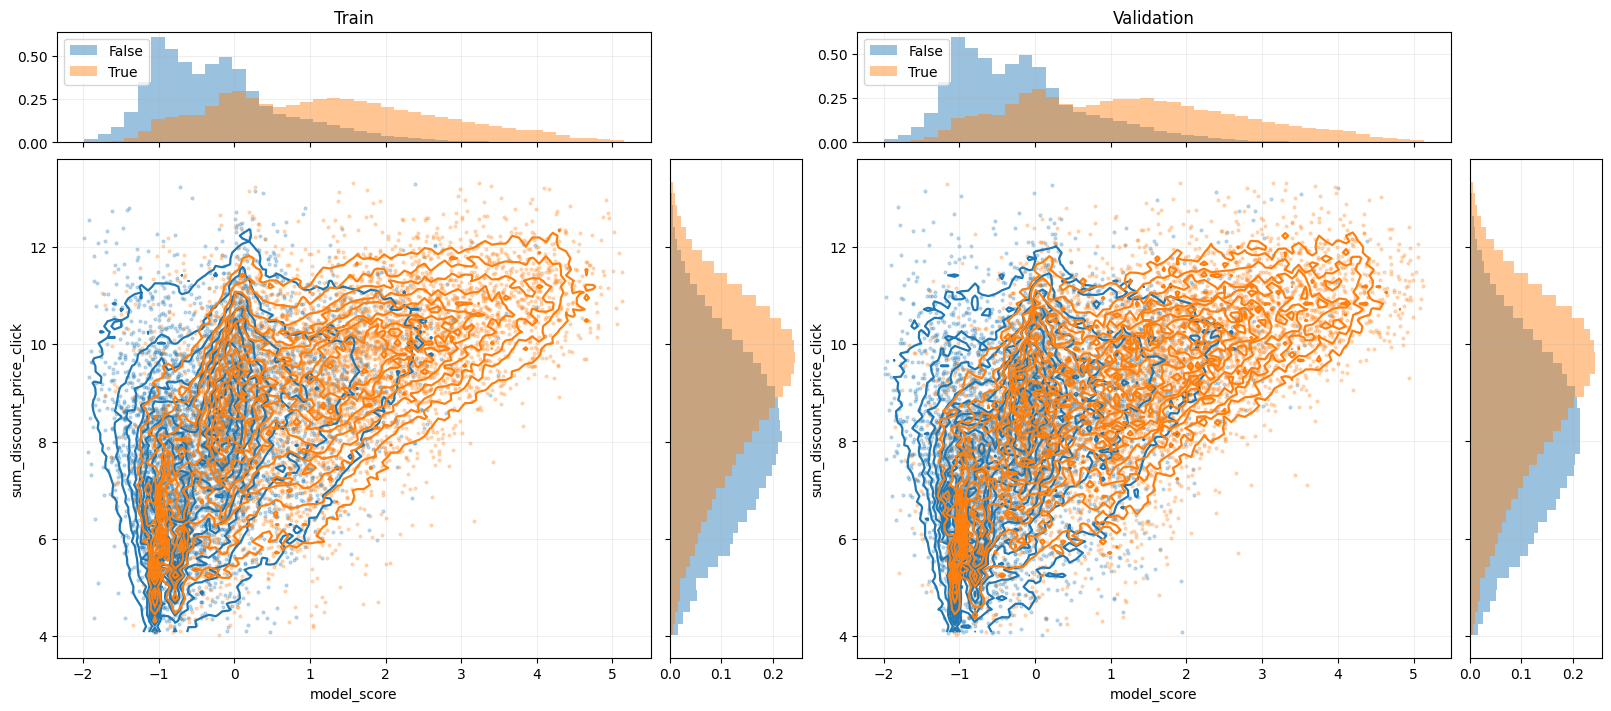

In [ ]:
interpreter.plot_score_feature_contours(feature_name="sum_discount_price_click")

In [83]:
interpreter.plot_shap_beeswarm(max_display=20, sample_size=5000);

Found a NULL input array in _cext_dense_tree_update_weights!


ExplainerError: Currently TreeExplainer can only handle models with categorical splits when feature_perturbation="tree_path_dependent" and no background data is passed. Please try again using shap.TreeExplainer(model, feature_perturbation="tree_path_dependent").

In [ ]:
train_pool = catboost.Pool(
    X_train,
    label=y_train,
)
eval_pool = catboost.Pool(
    X_val,
    label=y_val,
)

In [ ]:
train_pool.shape, eval_pool.shape

((1311636, 23), (563320, 23))

In [ ]:
model.fit(
    train_pool, 
    eval_set=eval_pool,
    use_best_model=True,
    verbose=10,
    early_stopping_rounds=50,
)

Default metric period is 5 because AUC is/are not implemented for GPU


0:	test: 0.7464139	best: 0.7464139 (0)	total: 10.8ms	remaining: 21.6s
10:	test: 0.7533818	best: 0.7533818 (10)	total: 109ms	remaining: 19.7s
20:	test: 0.7544571	best: 0.7544571 (20)	total: 211ms	remaining: 19.9s
30:	test: 0.7551281	best: 0.7551281 (30)	total: 301ms	remaining: 19.1s
40:	test: 0.7556111	best: 0.7556111 (40)	total: 391ms	remaining: 18.7s
50:	test: 0.7559006	best: 0.7559104 (49)	total: 482ms	remaining: 18.4s
60:	test: 0.7563458	best: 0.7563458 (60)	total: 576ms	remaining: 18.3s
70:	test: 0.7566409	best: 0.7566409 (70)	total: 667ms	remaining: 18.1s
80:	test: 0.7568346	best: 0.7568346 (80)	total: 760ms	remaining: 18s
90:	test: 0.7569607	best: 0.7569607 (90)	total: 854ms	remaining: 17.9s
100:	test: 0.7571425	best: 0.7571425 (100)	total: 948ms	remaining: 17.8s
110:	test: 0.7573377	best: 0.7573377 (110)	total: 1.04s	remaining: 17.7s
120:	test: 0.7574423	best: 0.7574423 (120)	total: 1.13s	remaining: 17.5s
130:	test: 0.7575461	best: 0.7575461 (130)	total: 1.22s	remaining: 17.4s
1

In [84]:
name = 'baseline1'
model.save_model(f"{name}.bin")

In [85]:
fi = model.get_feature_importance(eval_pool, prettified=True)
fi.head(50)

NameError: name 'eval_pool' is not defined

In [86]:
test_users_submission = (
    pl.read_csv(os.path.join(data_path, 'test_users.csv'))
)

In [87]:
val_end_date, val_end_date - timedelta(days=30 * 4)

(datetime.date(2024, 7, 31), datetime.date(2024, 4, 2))

In [ ]:
actions_aggs = {}
actions_id_to_suf = {
    1: "click",
    2: "favorite",
    3: "order",
    5: "to_cart",
}
for id_, suf in actions_id_to_suf.items():
    aggs = (
        actions_history
        .filter(pl.col('timestamp').dt.date() <= val_end_date)
        .filter(pl.col('timestamp').dt.date() >= val_end_date - timedelta(days=30 * 4))
        .filter(pl.col('action_type') == suf)
        .join(
            product_information
            .select('product_id', 'discount_price'),
            on='product_id',
        )
        .group_by('user_id')
        .agg(
            pl.count('product_id').cast(pl.Int32).alias(f'num_products_{suf}'),
            pl.sum('discount_price').cast(pl.Float32).alias(f'sum_discount_price_{suf}'),
            pl.max('discount_price').cast(pl.Float32).alias(f'max_discount_price_{suf}'),
            pl.max('timestamp').alias(f'last_{suf}_time'),
            pl.min('timestamp').alias(f'first_{suf}_time'),
        )
        .with_columns([
            (pl.lit(test_start_date) - pl.col(f'last_{suf}_time'))
            .dt.total_days()
            .cast(pl.Int32)
            .alias(f'days_since_last_{suf}'),
            
            (pl.lit(test_start_date) - pl.col(f'first_{suf}_time'))
            .dt.total_days()
            .cast(pl.Int32)
            .alias(f'days_since_first_{suf}'),
        ])
        .select(
            'user_id',
            f'num_products_{suf}',
            f'sum_discount_price_{suf}',
            f'max_discount_price_{suf}',
            f'days_since_last_{suf}',
            f'days_since_first_{suf}',
        )
    )
    actions_aggs[id_] = aggs

In [ ]:
# search_aggs
id_ = 4
suf = 'search'
actions_aggs[id_] = (
    search_history
    .filter(pl.col('action_type_id') == id_)
    .filter(pl.col('timestamp').dt.date() <= val_end_date)
    .filter(pl.col('timestamp').dt.date() >= val_end_date - timedelta(days=30 * 4))
    .group_by('user_id')
    .agg(
        pl.count('search_query').cast(pl.Int32).alias(f'num_{suf}'),
        pl.max('timestamp').alias(f'last_{suf}_time'),
        pl.min('timestamp').alias(f'first_{suf}_time'),
    )
    .with_columns([
        (pl.lit(test_start_date) - pl.col(f'last_{suf}_time'))
        .dt.total_days()
        .cast(pl.Int32)
        .alias(f'days_since_last_{suf}'),

        (pl.lit(test_start_date) - pl.col(f'first_{suf}_time'))
        .dt.total_days()
        .cast(pl.Int32)
        .alias(f'days_since_first_{suf}'),
    ])
    .select(
        'user_id',
        f'num_{suf}',
        f'days_since_last_{suf}',
        f'days_since_first_{suf}',
    )
)

In [ ]:
df = test_users_submission
for _, actions_aggs_df in actions_aggs.items():
    df = (
        df
        .join(actions_aggs_df, on='user_id', how='left')
    )

In [ ]:
df_pd = df.to_pandas()

In [ ]:
df_pd.shape

(2068424, 24)

In [ ]:
df_pd['predict'] = model.predict(df_pd[cols], prediction_type="Probability")[:, 1]

In [ ]:
df_pd[['user_id', 'predict']]

,user_id,predict
0,1342,0.354490
1,9852,0.807450
2,10206,0.351731
3,11317,0.347183
4,13289,0.427292
...,...,...
2068419,11157283,0.325582
2068420,11160395,0.227888
2068421,11165052,0.590995
2068422,11168218,0.687916


In [ ]:
df_pd[['user_id', 'predict']].to_csv('baseline1_submission.csv', index=False)